## NLP END-TO-END PROJECT: E-COMMERCE REVIEW SENTIMENT ANALYSIS

#### Load the Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#### Download essential NLTK linguistic resources

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Randhir
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Randhir
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Randhir
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#### LOAD DATASET

In [3]:
df= pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

#### Showing few rows

In [4]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
df.tail()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


#### Shape check

In [6]:
df.shape

(23486, 11)

#### Data type check

In [7]:
df.dtypes

Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

#### Dataset Info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


#### Statistical summary

In [9]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


#### check Unique Values

In [10]:
df.nunique()

Unnamed: 0                 23486
Clothing ID                 1206
Age                           77
Title                      13993
Review Text                22634
Rating                         5
Recommended IND                2
Positive Feedback Count       82
Division Name                  3
Department Name                6
Class Name                    20
dtype: int64

#### check number of rating 1 to 5

In [11]:
df['Rating'].value_counts()

Rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64

## Data Cleaning Technique

#### Check duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

#### check Missing Values

In [13]:
df.isnull()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
23481,False,False,False,False,False,False,False,False,False,False,False
23482,False,False,False,False,False,False,False,False,False,False,False
23483,False,False,False,False,False,False,False,False,False,False,False
23484,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

#### with barchart to check missing value

<Axes: >

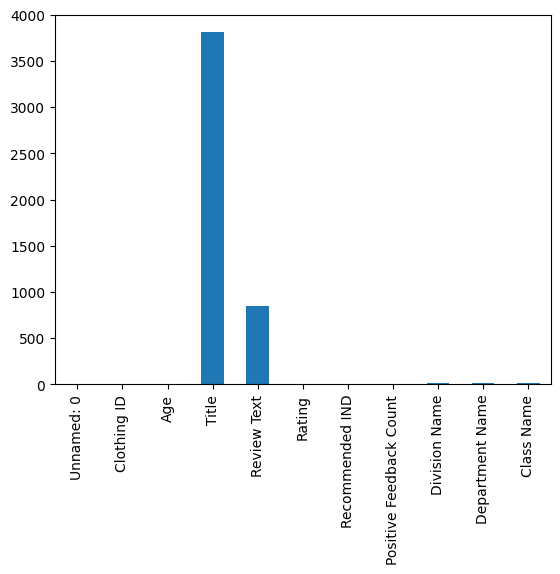

In [15]:
df.isnull().sum().plot(kind='bar')

In [16]:
# Unnamed: 0 sirf index column hai, Clothing ID product code hai
# Inhe drop kar dete hain aur jahan Review Text null hai un rows ko remove karte hain
df = df.drop(columns=['Unnamed: 0', 'Clothing ID'], errors='ignore')
df = df.dropna(subset=['Review Text']).reset_index(drop=True)

# Title null hone par blank string assign karte hain aur combine karte hain
df['Title'] = df['Title'].fillna('')
df['Review'] = df['Title'] + ' ' + df['Review Text']

df.head()

,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and com...
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happen...
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumps..."
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering...


#### Rating & Recommendation Statistics

In [17]:
# Rating distribution check karna
print('Rating Value Counts:')
print(df['Rating'].value_counts())

print('\nRating Summary:')
print(df['Rating'].describe())

Rating Value Counts:
Rating
5    12540
4     4908
3     2823
2     1549
1      821
Name: count, dtype: int64

Rating Summary:
count    22641.000000
mean         4.183561
std          1.115762
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


#### Recommended IND ka distribution

In [18]:
print('\nRecommended IND Counts:')
print(df['Recommended IND'].value_counts())


Recommended IND Counts:
Recommended IND
1    18540
0     4101
Name: count, dtype: int64


C:\Users\Randhir kumar\AppData\Local\Temp\ipykernel_20880\566084792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Rating'], palette='viridis')


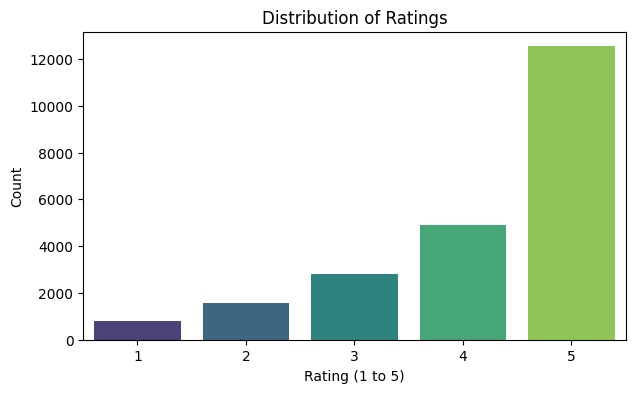

In [19]:
# Countplot of Ratings
plt.figure(figsize=(7, 4))
sns.countplot(x=df['Rating'], palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (1 to 5)')
plt.ylabel('Count')
plt.show()

C:\Users\Randhir kumar\AppData\Local\Temp\ipykernel_20880\3456610867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Recommended IND'], palette='coolwarm')


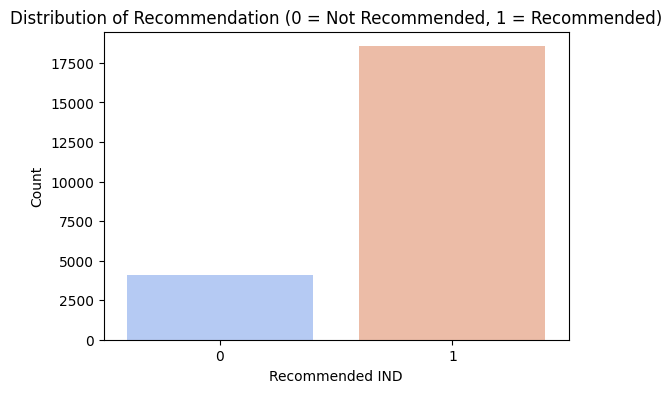

In [20]:
# Countplot of Recommended IND (0 = No, 1 = Yes)
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Recommended IND'], palette='coolwarm')
plt.title('Distribution of Recommendation (0 = Not Recommended, 1 = Recommended)')
plt.xlabel('Recommended IND')
plt.ylabel('Count')
plt.show()

#### Outliers Detection

<Figure size 800x400 with 0 Axes>

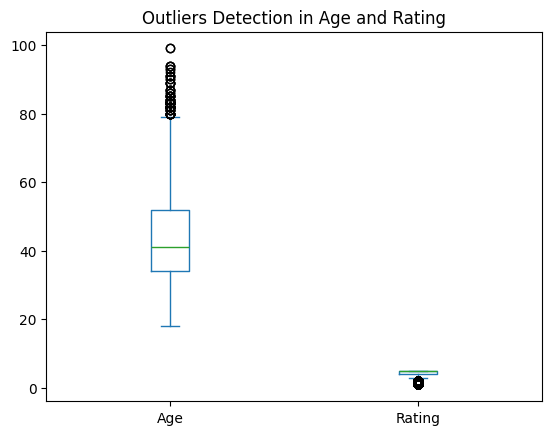

In [21]:
# Boxplot for Ratings & Age
plt.figure(figsize=(8, 4))
df[['Age', 'Rating']].plot(kind='box')
plt.title('Outliers Detection in Age and Rating')
plt.show()

#### Age ke liye IQR (Interquartile Range) calculate karna

In [22]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Age Lower Limit: {lower_limit}")
print(f"Age Upper Limit: {upper_limit}")
print(f"Age Outliers Count: {len(df[(df['Age'] < lower_limit) | (df['Age'] > upper_limit)])}")

# 2. Age outliers ko filter karna (Rating ko chhede bina)
# Sirf valid age range (18 se lekar upper_limit tak) ke records rakhein
df = df[(df['Age'] >= 18) & (df['Age'] <= upper_limit)].reset_index(drop=True)

print("Dataset Shape after removing Age outliers:", df.shape)

Age Lower Limit: 7.0
Age Upper Limit: 79.0
Age Outliers Count: 108
Dataset Shape after removing Age outliers: (22533, 10)


#### Check clean Age boxplot

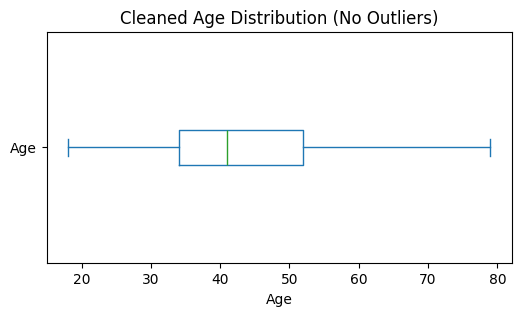

In [23]:
plt.figure(figsize=(6, 3))
df['Age'].plot(kind='box', vert=False)
plt.title('Cleaned Age Distribution (No Outliers)')
plt.xlabel('Age')
plt.show()

#### Target Engineering - Create Sentiment Column

In [24]:
# Calculate key metrics
avg_rating = df['Rating'].mean()
positive_pct = (len(df[df['Rating'] >= 4]) / len(df)) * 100
neutral_pct = (len(df[df['Rating'] == 3]) / len(df)) * 100
negative_pct = (len(df[df['Rating'] <= 2]) / len(df)) * 100
recommend_pct = (len(df[df['Recommended IND'] == 1]) / len(df)) * 100

print('\nKey Insights:')
print(f'1. Average Rating: {avg_rating:.2f}/5')
print(f'2. Positive Rating (4-5 stars): {positive_pct:.1f}%')
print(f'3. Neutral Rating (3 stars): {neutral_pct:.1f}%')
print(f'4. Negative Rating (1-2 stars): {negative_pct:.1f}%')
print(f'5. Customer Recommendation Rate: {recommend_pct:.1f}%')


Key Insights:
1. Average Rating: 4.18/5
2. Positive Rating (4-5 stars): 77.0%
3. Neutral Rating (3 stars): 12.5%
4. Negative Rating (1-2 stars): 10.5%
5. Customer Recommendation Rate: 81.9%


#### Creating new column named 'Sentiment'

In [25]:

df['Sentiment'] = df['Rating'].apply(
    lambda x: 'Positive' if x >= 4 else ('Neutral' if x == 3 else 'Negative')
)
df[['Review', 'Rating', 'Sentiment', 'Recommended IND']].head(10)

,Review,Rating,Sentiment,Recommended IND
0,Absolutely wonderful - silky and sexy and com...,4,Positive,1
1,Love this dress! it's sooo pretty. i happen...,5,Positive,1
2,Some major design flaws I had such high hopes ...,3,Neutral,0
3,"My favorite buy! I love, love, love this jumps...",5,Positive,1
4,Flattering shirt This shirt is very flattering...,5,Positive,1
5,Not for the very petite I love tracy reese dre...,2,Negative,0
6,Cagrcoal shimmer fun I aded this in my basket ...,5,Positive,1
7,"Shimmer, surprisingly goes with lots I ordered...",4,Positive,1
8,Flattering I love this dress. i usually get an...,5,Positive,1
9,"Such a fun dress! I'm 5""5' and 125 lbs. i orde...",5,Positive,1


### Text Preprocessing Step-by-Step

#### Lowercasing

In [26]:
df['Clean_Review'] = df['Review'].astype(str).str.lower()
df[['Review', 'Clean_Review']].head(3)

,Review,Clean_Review
0,Absolutely wonderful - silky and sexy and com...,absolutely wonderful - silky and sexy and com...
1,Love this dress! it's sooo pretty. i happen...,love this dress! it's sooo pretty. i happen...
2,Some major design flaws I had such high hopes ...,some major design flaws i had such high hopes ...


#### Remove Punctuation & Special Characters

In [27]:
import string

exclude = string.punctuation


def remove_punctuation(text):
  text = text.translate(str.maketrans("", "", exclude))
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text


df["Clean_Review"] = df["Clean_Review"].apply(remove_punctuation)
df["Clean_Review"].head(3)

0    absolutely wonderful silky and sexy and comfor...
1    love this dress its sooo pretty i happened to ...
2    some major design flaws i had such high hopes ...
Name: Clean_Review, dtype: str

#### Tokenization

In [28]:
# Word tokenization using nltk
from nltk.tokenize import word_tokenize

df['Tokens'] = df['Clean_Review'].apply(word_tokenize)
df[['Clean_Review', 'Tokens']].head(3)

,Clean_Review,Tokens
0,absolutely wonderful silky and sexy and comfor...,"[absolutely, wonderful, silky, and, sexy, and,..."
1,love this dress its sooo pretty i happened to ...,"[love, this, dress, its, sooo, pretty, i, happ..."
2,some major design flaws i had such high hopes ...,"[some, major, design, flaws, i, had, such, hig..."


#### Stopwords Removal

In [29]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Important negative words ko remove hone se bachao
stop_words -= {'not', 'no', 'nor', 'never'}

# Lemmatizer
lemmatizer = WordNetLemmatizer()

# Text preprocessing function
def clean_text(text):
    # Lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and w.isalpha()
    ]

    return ' '.join(words)

#### Lemmatization & Rejoining

In [30]:

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


def lemmatize_words(tokens_list):
  lemmatized = [lemmatizer.lemmatize(word) for word in tokens_list]
  return ' '.join(lemmatized)


df['Processed_Review'] = df['Tokens'].apply(lemmatize_words)
df[['Review', 'Processed_Review', 'Sentiment', 'Recommended IND']].head(5)

,Review,Processed_Review,Sentiment,Recommended IND
0,Absolutely wonderful - silky and sexy and com...,absolutely wonderful silky and sexy and comfor...,Positive,1
1,Love this dress! it's sooo pretty. i happen...,love this dress it sooo pretty i happened to f...,Positive,1
2,Some major design flaws I had such high hopes ...,some major design flaw i had such high hope fo...,Neutral,0
3,"My favorite buy! I love, love, love this jumps...",my favorite buy i love love love this jumpsuit...,Positive,1
4,Flattering shirt This shirt is very flattering...,flattering shirt this shirt is very flattering...,Positive,1


#### Feature Extraction (TF-IDF Vectorization)

In [31]:
# TF-IDF Vectorizer apply karna
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Processed_Review'])

print('TF-IDF Feature Matrix Shape:', X.shape)

TF-IDF Feature Matrix Shape: (22533, 5000)


In [32]:
# Save vectorizer file
import pickle

with open('vectorizer.pkl', 'wb') as f:
  pickle.dump(vectorizer, f)
print("vectorizer.pkl successfully save ho gaya!")

vectorizer.pkl successfully save ho gaya!


#### Model Building (Sentiment & Recommendation)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Targets define karna
# Sentiment: 0 = Negative, 1 = Positive, 2 = Neutral
y_sentiment = np.where(
    df['Sentiment'] == 'Positive', 1, np.where(df['Sentiment'] == 'Neutral', 2, 0)
)

# Recommendation: 0 = No, 1 = Yes
y_recommendation = df['Recommended IND'].values

# Train-Test Split (80% Train, 20% Test)
(
    X_train,X_test,y_sent_train, y_sent_test,y_rec_train,y_rec_test,) = train_test_split(
    X, y_sentiment, y_recommendation, test_size=0.2, random_state=42
)

In [34]:
# 1. Train Sentiment Model
sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train, y_sent_train)

# Evaluation
y_sent_pred = sentiment_model.predict(X_test)
print('=== Sentiment Analysis Classification Report ===')
print(
    classification_report(
        y_sent_test,
        y_sent_pred,
        target_names=['Negative', 'Positive', 'Neutral'],
    )
)

=== Sentiment Analysis Classification Report ===
              precision    recall  f1-score   support

    Negative       0.65      0.48      0.55       443
    Positive       0.88      0.97      0.92      3470
     Neutral       0.49      0.27      0.35       594

    accuracy                           0.83      4507
   macro avg       0.67      0.58      0.61      4507
weighted avg       0.80      0.83      0.81      4507



#### with naive bayas

In [35]:
#  from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.model_selection import train_test_split

# # Targets define karna
# # Sentiment: 0 = Negative, 1 = Positive, 2 = Neutral
# y_sentiment = np.where(
#     df['Sentiment'] == 'Positive', 1, np.where(df['Sentiment'] == 'Neutral', 2, 0)
# )

# # Recommendation: 0 = No, 1 = Yes
# y_recommendation = df['Recommended IND'].values

# # Train-Test Split (80% Train, 20% Test)
# (
#     X_train,X_test,y_sent_train, y_sent_test,y_rec_train,y_rec_test,) = train_test_split(
#     X, y_sentiment, y_recommendation, test_size=0.2, random_state=42
# )  

In [36]:
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import classification_report

# # 1. Train Sentiment Model
# sentiment_model = MultinomialNB()
# sentiment_model.fit(X_train, y_sent_train)

# # Evaluation
# y_sent_pred = sentiment_model.predict(X_test)
# print('=== Sentiment Analysis Classification Report ===')
# print(
#     classification_report(
#         y_sent_test,
#         y_sent_pred,
#         target_names=['Negative', 'Positive', 'Neutral'],
#     )
# )

In [37]:
# 2. Train Recommendation Model
rec_model = LogisticRegression(max_iter=1000)
rec_model.fit(X_train, y_rec_train)

# Evaluation
y_rec_pred = rec_model.predict(X_test)
print('=== Customer Recommendation Classification Report ===')
print(
    classification_report(
        y_rec_test, y_rec_pred, target_names=['Not Recommended', 'Recommended']
    )
)

=== Customer Recommendation Classification Report ===
                 precision    recall  f1-score   support

Not Recommended       0.80      0.58      0.67       788
    Recommended       0.92      0.97      0.94      3719

       accuracy                           0.90      4507
      macro avg       0.86      0.77      0.81      4507
   weighted avg       0.89      0.90      0.89      4507



In [38]:
# Save both models
with open('sentiment_model.pkl', 'wb') as f:
  pickle.dump(sentiment_model, f)

with open('recommendation_model.pkl', 'wb') as f:
  pickle.dump(rec_model, f)

print("sentiment_model.pkl aur recommendation_model.pkl save ho gaye!")

sentiment_model.pkl aur recommendation_model.pkl save ho gaye!


In [41]:
# Final testing function for end-user review

def predict_review(new_review):
    # 1. Cleaning
    text = new_review.lower()
    text = text.translate(str.maketrans('', '', exclude))
    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and w.isalpha()
    ]

    cleaned_text = ' '.join(words)

    # 2. Vectorize
    input_vec = vectorizer.transform([cleaned_text])

    # 3. Predict Sentiment
    sent_pred = sentiment_model.predict(input_vec)[0]
    sent_map = {
        1: 'Positive 😊',
        2: 'Neutral 😐',
        0: 'Negative 😞'
    }

    # 4. Predict Recommendation
    rec_pred = rec_model.predict(input_vec)[0]
    rec_map = {
        1: 'Yes, Customer will Recommend 👍',
        0: 'No, Not Recommended 👎'
    }

    print(f'User Review: "{new_review}"')
    print(f'Detected Sentiment: {sent_map[sent_pred]}')
    print(f'Recommendation Prediction: {rec_map[rec_pred]}')
    print('-' * 60)


# Test examples
predict_review('I love this dress! The fabric is soft and fitting is absolutely perfect.')

predict_review('shirt is not good.')

predict_review('The shirt is okay. The fabric is average, and the fitting is neither too good nor too ba.')

User Review: "I love this dress! The fabric is soft and fitting is absolutely perfect."
Detected Sentiment: Positive 😊
Recommendation Prediction: Yes, Customer will Recommend 👍
------------------------------------------------------------
User Review: "shirt is not good."
Detected Sentiment: Negative 😞
Recommendation Prediction: No, Not Recommended 👎
------------------------------------------------------------
User Review: "The shirt is okay. The fabric is average, and the fitting is neither too good nor too ba."
Detected Sentiment: Neutral 😐
Recommendation Prediction: No, Not Recommended 👎
------------------------------------------------------------
